In [10]:
import torch as tc
import torchvision.transforms.v2 as tvs
from torchvision.datasets import ImageFolder

transforms = tvs.Compose([
    # tvs.Grayscale(),
    tvs.ToImage(),
    tvs.ToDtype(tc.float32, scale=True),
    tvs.Resize(100),
    tvs.CenterCrop(100),
    # tvs.Normalize(mean=(0.5,), std=(0.5,)),
])
data_source = ImageFolder("data/cats_and_dogs/PetImages", transform=transforms)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


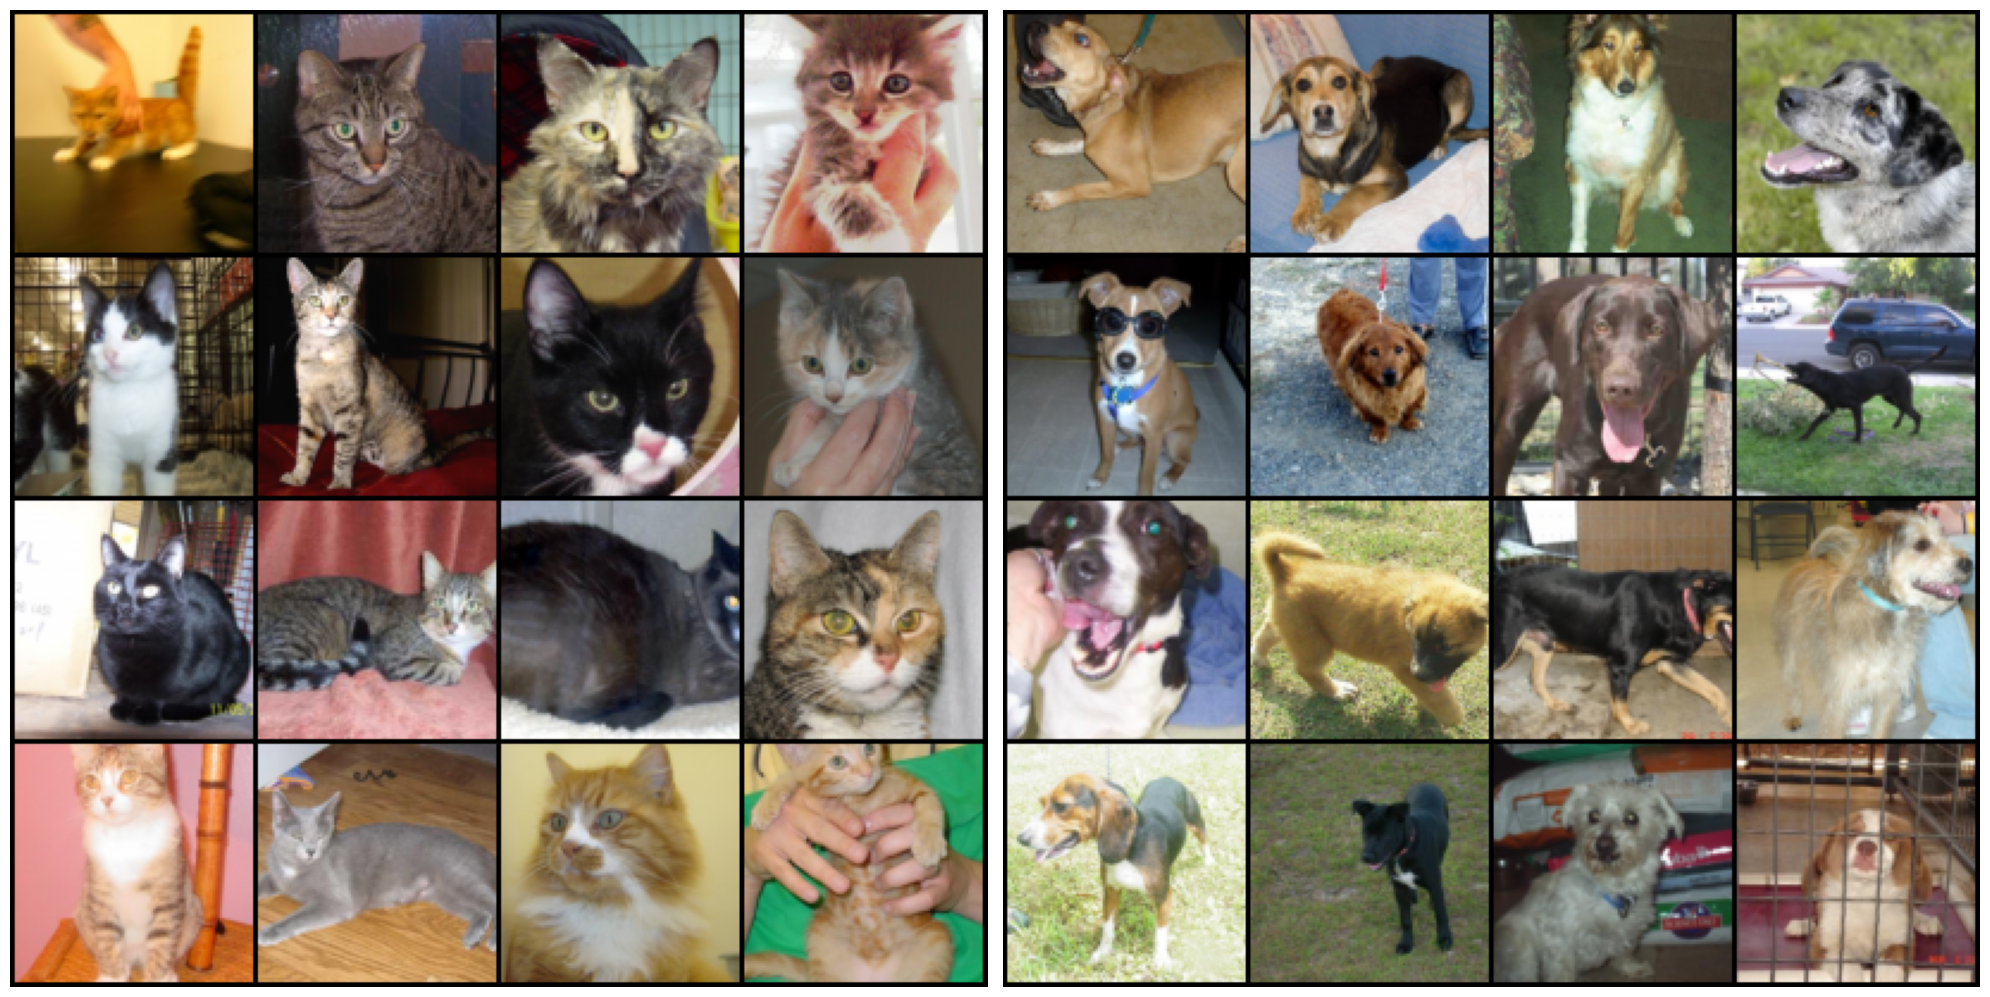

In [11]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

N: int = 4

CATS = [i for i in range(N * N)]
DOGS = [i + 13000 for i in range(N * N)]
cat_examples = tc.stack([data_source[i][0] for i in CATS])
dog_examples = tc.stack([data_source[i][0] for i in DOGS])

fig, axes = plt.subplots(ncols=2, figsize=(20, 20))
axes[0].imshow(make_grid(cat_examples, nrow=N).movedim(0, -1), cmap="gray")
axes[0].set_axis_off()
axes[1].imshow(make_grid(dog_examples, nrow=N).movedim(0, -1), cmap="gray")
axes[1].set_axis_off()
plt.tight_layout()
plt.savefig("images/cats_vs_dogs_preview.png")